In [17]:
from profiling_and_attack import mlp_eshard, information, cnn, mlp

from sklearn.preprocessing import StandardScaler
from utils import *
from tensorflow.keras import Model
from tensorflow.keras.utils import to_categorical
from sklearn.decomposition import PCA
import sys
from matplotlib import pyplot as plt

In [18]:
import tensorflow as tf

def train_linear_probe(x_train, y_train, epochs=5):
    """
    Defines and trains a linear probe with a dense layer on top of extracted features.
    
    Args:
        x_train (np.array or tf.Tensor): Training features.
        y_train (np.array or tf.Tensor): Training labels.
        
    Returns:
        tf.keras.Model: Trained linear probe model.
    """
    # Define the linear probe model (a simple dense layer on the input features)
    num_classes = len(set(y_train))  # Infer number of classes from labels
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=x_train.shape[1:]),  # Input shape based on feature size
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    # Compile the model
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    # Train the linear probe
    model.fit(x_train, y_train, epochs=epochs, batch_size=400)

    return model

In [19]:
dataset_id = 'ascad-variable'
resample_window=80
traces_dim = 2000
model = mlp(256,traces_dim)
n_prof= 200000

def hw(input):

    result = np.zeros_like(input)
    for i in range(8):
        result += (input >> i) & 0x1
    return result


lm = "ID"
target_byte = 2
path = "/mnt/d/Datasets"
dataset = load_dataset(dataset_id, path, target_byte, traces_dim, leakage_model=lm, n_prof=n_prof)
pi_og, pi_patch_new, pi_patch_og = [], [], []
dataset.x_profiling, dataset.x_attack = scale_dataset(dataset.x_profiling, dataset.x_attack, StandardScaler())


Model: "mlp_softmax"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 2000)]            0         
                                                                 
 dense_18 (Dense)            (None, 100)               200100    
                                                                 
 dense_19 (Dense)            (None, 100)               10100     
                                                                 
 dense_20 (Dense)            (None, 100)               10100     
                                                                 
 dense_21 (Dense)            (None, 100)               10100     
                                                                 
 dense_22 (Dense)            (None, 100)               10100     
                                                                 
 dense_23 (Dense)            (None, 100)               

In [20]:
layers = ["conv_1", "conv_2","fc_1", "fc_2"]

input_layers = ["bn_1", "bn_2", "fc_2", "output"]

In [21]:
def reload_model(epoch= 10, layers=1):
    global layer, model, tmp, tmp_att
    layer = layers
    model.load_weights(f"model_checkpoints/mlp_ascadr_{epoch:02d}.weights.h5")
    outputs = [model.layers[layer].output for layer in range(0, len(model.layers))]
    new_model = Model(model.inputs, outputs)
    tmp =  new_model.predict(dataset.x_profiling)
    #print(tmp.shape)
    tmp_att = new_model.predict(dataset.x_attack).copy()
# if layers[layer].__contains__("conv"):
#     og_1, og_2 = tmp.shape[1], tmp.shape[2]
#     tmp = tmp.reshape(tmp.shape[0], og_1*og_2)
#     #print(tmp.shape)
#     s1_att = s1_att.reshape(s1_att.shape[0], og_1*og_2)
reload_model()


313/313 [==============================] - 0s 1ms/step


In [22]:
tmp[layer].shape
snr = snr_fast(tmp[layer], dataset.share5_profiling[target_byte])
#np.min(tmp)
snr


array([0.13441931, 0.00988477, 0.03912871, 0.02413129, 0.0664468 ,
       0.01023357, 0.06065469, 0.14938428, 0.00439472, 0.25471141,
       0.03668561, 0.31750983, 0.01452047, 0.15323056, 0.0169967 ,
       0.06821661, 0.16213313, 0.44746998, 0.02017842, 0.01019916,
       0.0032868 , 0.16605568, 0.23343442, 0.04808956, 0.02505723,
       0.17591439, 0.01795659, 0.01029895, 0.00575739, 0.19261374,
       0.05702207, 0.01381239, 0.20063915, 0.10572817, 0.00543566,
       0.32038401, 0.23189189, 0.02920006, 0.03212244, 0.04241056,
       0.01071412, 0.61333615, 0.30138218, 0.06550538, 0.57161176,
       0.00652   , 0.17554032, 0.01711684, 0.00876844, 0.02967457,
       0.41496288, 0.01510072, 0.02803875, 0.08647725, 0.01328166,
       0.00246258, 0.01686561, 0.05508142, 0.08906255, 0.00831088,
       0.42494687, 0.24205495, 0.0101544 , 0.18529815, 0.0052566 ,
       0.29269771, 0.00511499, 0.36811689, 0.02460293, 0.00730159,
       0.03214312, 0.07177371, 0.31557467, 0.07079716, 0.05405

In [23]:
#Detetrmine appropriate number of componenets:
reload_model(99)
new_model_out= Model(model.layers[layer+1].input, model.layers[-1].output)

orig_preds = new_model_out.predict(tmp_att[layer])
from profiling_and_attack import information
print(information(orig_preds, dataset.attack_labels, 256))
for comps in [2, 4, 8, 16, 32, 40]:
    pca = PCA(n_components=comps)
    pca.fit(tmp[layer])
    s1_prof = pca.transform(tmp_att[layer])
    ablated_preds = new_model_out.predict(pca.inverse_transform(s1_prof))

    print(comps, information(ablated_preds, dataset.attack_labels, 256))
    

313/313 [==============================] - 0s 776us/step
2.38193624260538
313/313 [==============================] - 0s 848us/step
2 -3.0546832558382246
313/313 [==============================] - 0s 987us/step
4 -1.1801306221712247
313/313 [==============================] - 0s 854us/step
8 -0.49560760733968734
313/313 [==============================] - 0s 896us/step
16 0.5792710013639287
313/313 [==============================] - 0s 979us/step
32 2.052391055227453
313/313 [==============================] - 0s 996us/step
40 2.2006198767911753


In [24]:

new_model_out= Model(model.layers[layer+1].input, model.layers[-1].output)
COMPS = 32
#orig_preds = model.predict(dataset.x_profiling)
pca = PCA(n_components=COMPS)
pca.fit(tmp[layer])
s1_prof = pca.transform(tmp_att[layer])

orig_preds = new_model_out.predict(pca.inverse_transform(s1_prof))
patched_activs = s1_prof.copy()

from profiling_and_attack import information
print(information(orig_preds, dataset.attack_labels, 256))
ablated_list_pis = []
for comp in range(s1_prof.shape[1]):
    patched_activs = s1_prof.copy()
    patched_activs[:, comp] = np.mean(s1_prof[:, comp])*0
    ablated_preds = new_model_out.predict(pca.inverse_transform(patched_activs))
    ablated_list_pis.append(information(ablated_preds, dataset.attack_labels, 256))
    print(comp, ablated_list_pis[-1])

patched_activs = s1_prof.copy()
for comp in range(20, s1_prof.shape[1]):
    
    patched_activs[:, comp] = np.mean(s1_prof[:, comp])

ablated_preds = new_model_out.predict(pca.inverse_transform(patched_activs))
print(information(ablated_preds, dataset.attack_labels, 256))

#patched_activs[:, COMP] *= 0
#patched_activs[weird_comp_off, 1] = 15
#print(patched_activs)




313/313 [==============================] - 0s 918us/step
2.030085277486971
313/313 [==============================] - 0s 913us/step
0 -1.0370231514681005
313/313 [==============================] - 0s 908us/step
1 -0.3792615517366542
313/313 [==============================] - 0s 904us/step
2 -2.3425200859773834
313/313 [==============================] - 0s 934us/step
3 0.5719860556852147
313/313 [==============================] - 0s 898us/step
4 0.7386887824308203
313/313 [==============================] - 0s 1ms/step
5 1.3077284064542571
313/313 [==============================] - 0s 895us/step
6 2.004947934652506
313/313 [==============================] - 0s 922us/step
7 1.7928966025602135
313/313 [==============================] - 0s 906us/step
8 1.8567720458280406
313/313 [==============================] - 0s 894us/step
9 1.9410112220060158
313/313 [==============================] - 0s 901us/step
10 1.0449451300870716
313/313 [==============================] - 0s 869us/step
11 1.6122

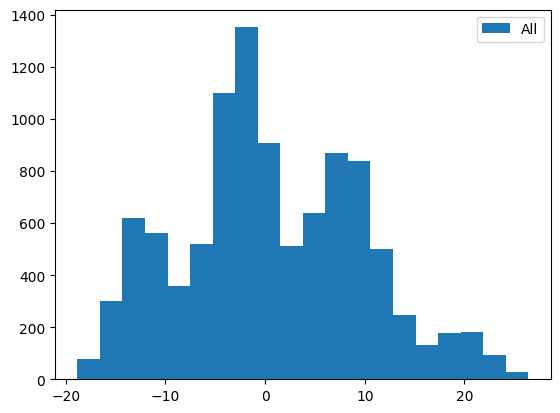

Neuron 0, 0.13441930696742949, 0.4749:    0: 1.0347685813903809, 128: 0.29090672731399536


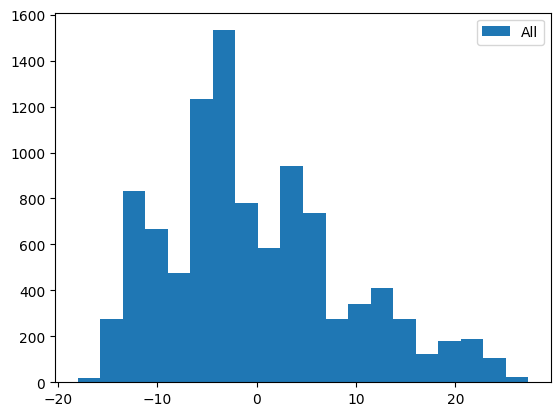

Neuron 1, 0.009884765336926782, 0.4215:    0: 0.07061120122671127, 128: -0.402773380279541


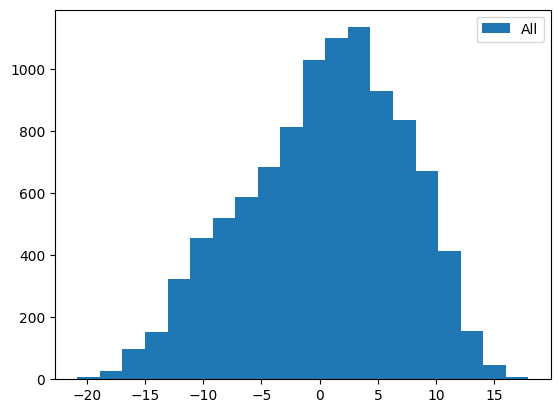

Neuron 2, 0.03912870924353145, 0.5566:    0: -0.5427491068840027, 128: 1.2706146240234375


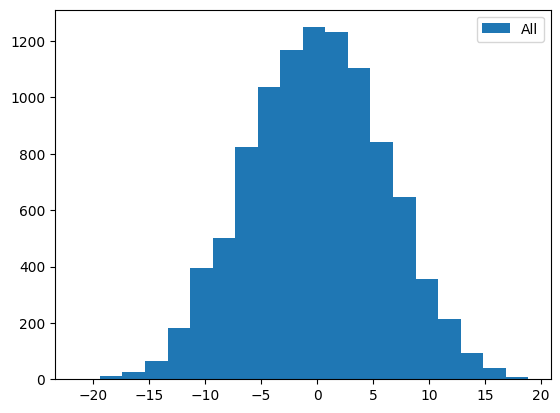

Neuron 3, 0.024131293163518017, 0.4964:    0: -2.8670477867126465, 128: 2.6318297386169434


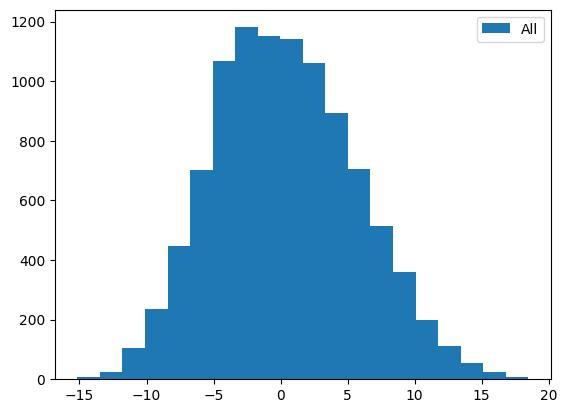

Neuron 4, 0.06644679832099547, 0.5062:    0: 2.759242296218872, 128: -1.9244236946105957


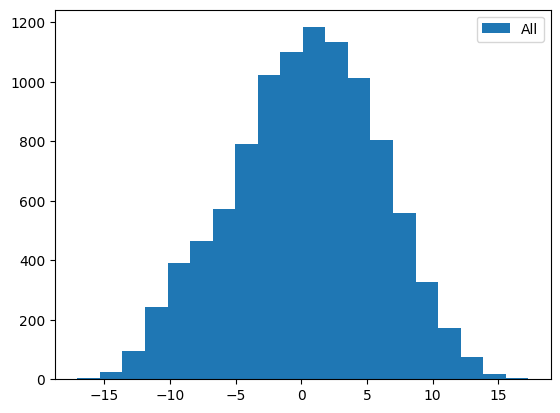

Neuron 5, 0.010233565622293422, 0.5364:    0: 0.8335020542144775, 128: -0.23517438769340515


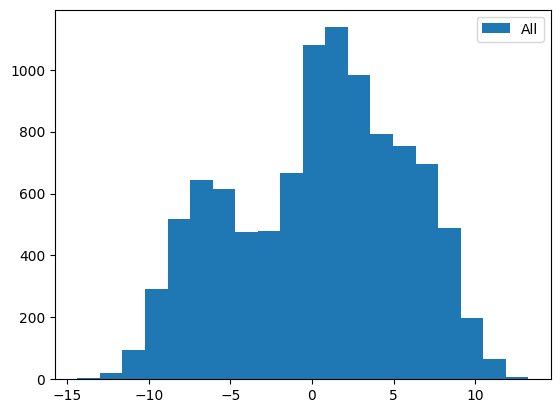

Neuron 6, 0.060654690433109566, 0.5791:    0: 0.4078446328639984, 128: 0.41803333163261414


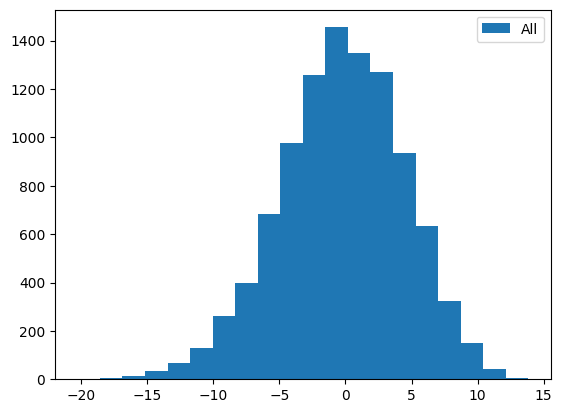

Neuron 7, 0.14938428435978185, 0.4877:    0: -0.9969139099121094, 128: 0.3720395863056183


In [25]:
bins=20
s1_att = pca.transform(tmp_att[layer])
for neuron in range(8):
    plt.hist(s1_att[:, neuron], bins, label=f"All")
    # for j in [0,1]:
    #     #indices = np.where(hw(dataset.share5_attack[target_byte].astype(np.uint8)) ==j)[0]
    #     indices = np.where(dataset.share5_profiling[target_byte, :] % 2 == j)[0] 
    #     plt.hist(s1_prof[indices, neuron], bins, label=f"Bit={j}", alpha=0.5)
    #     pass



    plt.legend()
    plt.show()

    mean, var = np.average(s1_att[:, neuron]), np.std(s1_att[:, neuron])
    avg0 = np.average(s1_att[np.where(dataset.share2_attack[target_byte]  % 2 ==0)[0], neuron])
    avg128 = np.average(s1_att[np.where(dataset.share2_attack[target_byte]% 2 ==1)[0], neuron])
    num_activs = len(np.where(s1_att[:, neuron] > 0)[0])/s1_att.shape[0]
    #avg255 = np.average(tmp_att[np.where(dataset.share5_attack[target_byte] == 255)[0], neuron])
    print(f"Neuron {neuron}, {snr[neuron]}, {num_activs}:    0: {avg0}, 128: {avg128}")

(200000, 16)
0 0.0001147678815761906
1 6.271580443650147e-05
2 0.00010371775772447504
3 7.702744171120352e-05
4 0.00015044092544095892
5 4.4956559017903095e-05
6 0.00028569319913306134
7 0.00046502645093685324


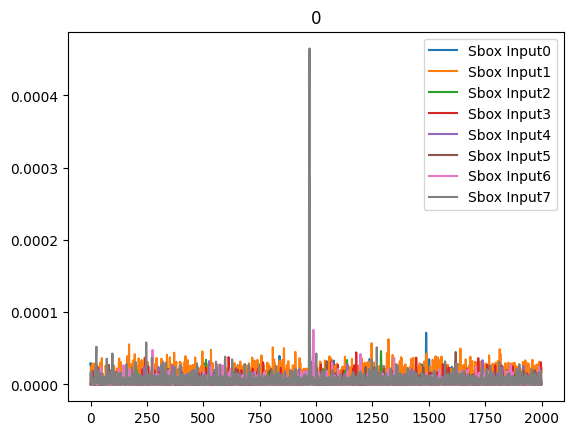

(200000, 16)
0 0.006954429594242818
1 0.03194323283408472
2 0.001286601673610306
3 0.0012460512092744907
4 0.0006946611952420069
5 0.0008101709021396886
6 0.0009342281771669881
7 0.001120241925794211


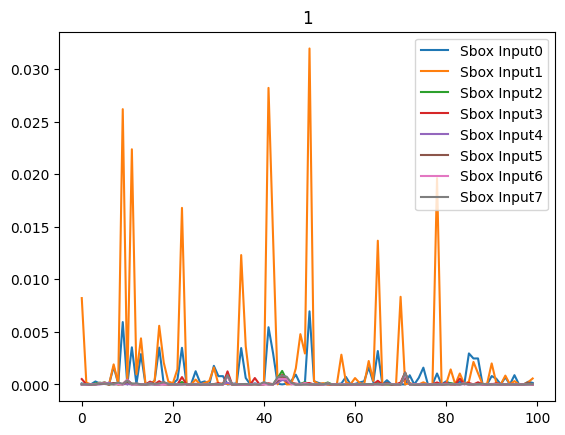

(200000, 16)
0 0.07361690778930977
1 0.10088100393312634
2 0.0034505880017713358
3 0.014982357354818673
4 0.0019851452093669958
5 0.0030265005944786344
6 0.003060797790927331
7 0.003578509750289981


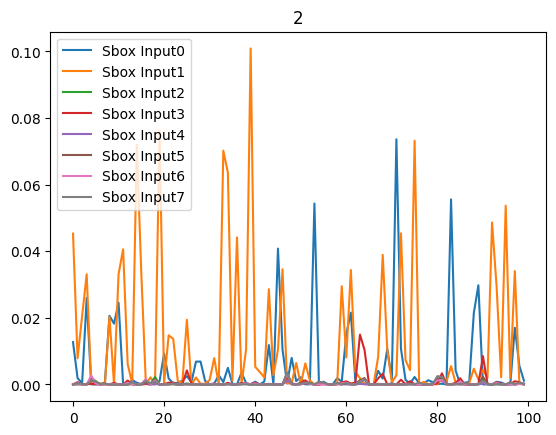

(200000, 16)
0 0.2007062737407251
1 0.3142203475457218
2 0.0127574244258499
3 0.024171338607049075
4 0.002981511646332141
5 0.016449943290570115
6 0.011681455534360874
7 0.010026763024731064


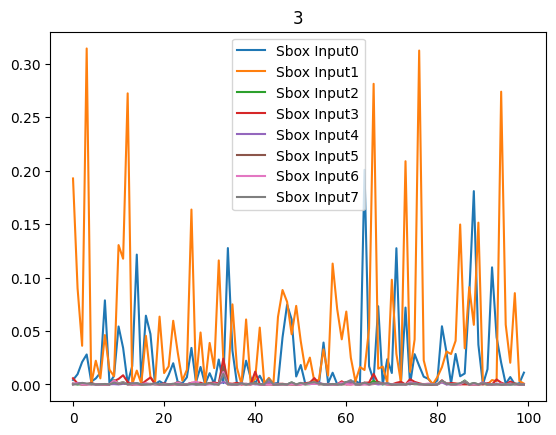

(200000, 16)
0 0.31878452332473023
1 0.70139944597358
2 0.012811586762426708
3 0.023756434335856474
4 0.003465843152004068
5 0.011408398959738037
6 0.011631878900255854
7 0.010678069144793937


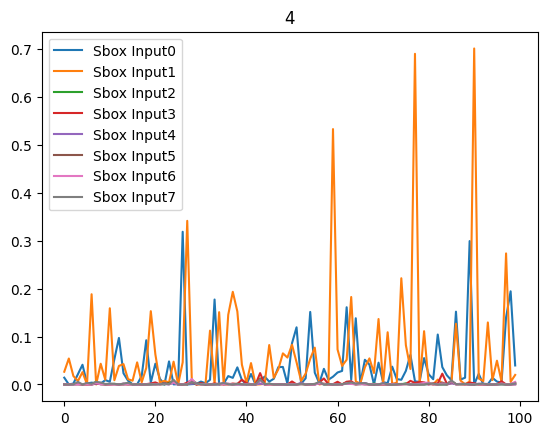

(200000, 16)
0 0.2499297313571672
1 0.988102701027729
2 0.011265272481685134
3 0.019305555617636253
4 0.006761569660800088
5 0.0096970198129205
6 0.009432651736522003
7 0.010087442078973585


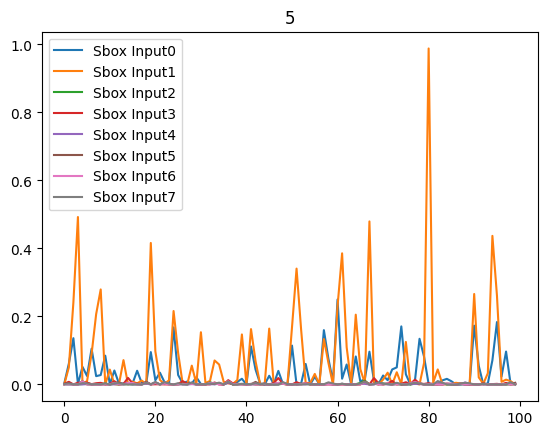

(200000, 16)
0 0.25645742853135145
1 0.4968096792919623
2 0.012395375459884918
3 0.02862694592606279
4 0.007025786117114051
5 0.01724177084632688
6 0.013212128301648383
7 0.018730164769285327


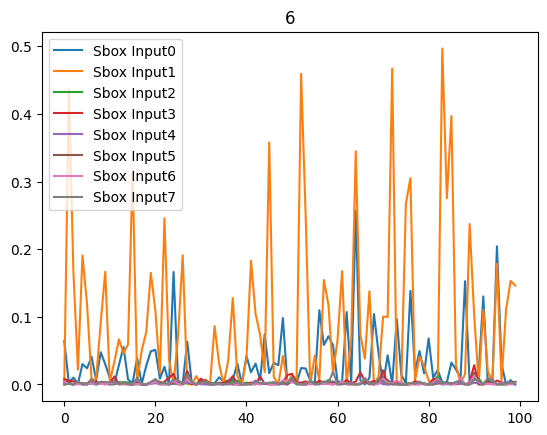

(200000, 16)
0 0.04383701377506313
1 0.04694946169398471
2 0.008201763791739633
3 0.009035666006219177
4 0.004552452447208041
5 0.008403999615394049
6 0.009426089053476644
7 0.008117211986753138


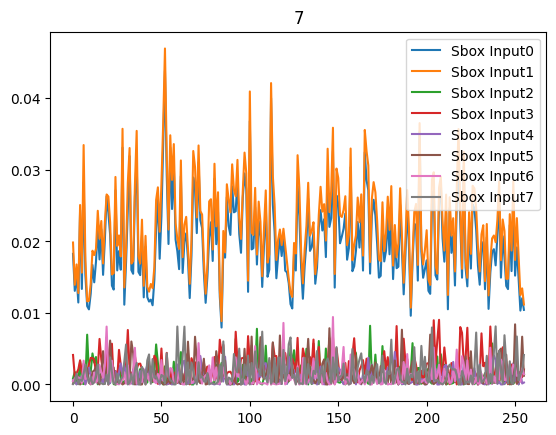

In [26]:
#print(tmp[0].shape)

for i in range(len(tmp)):
    print(dataset.profiling_plaintexts.shape)
    for j in range(8):
        snr_locals = snr_fast(tmp[i], ((dataset.profiling_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.profiling_keys[:, dataset.target_byte].astype(np.uint8))>>j)&0x1)
        print(j, max(snr_locals))
        plt.plot(snr_locals, label=f"Sbox Input{j}")
    #plt.plot(snr_fast(tmp[i], dataset.profiling_labels), label="Sbox")
    plt.legend()
    plt.title(i)
    plt.show()

In [226]:
sbox_ins = (dataset.profiling_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.profiling_keys[:, dataset.target_byte].astype(np.uint8))
probes_for_bit = []
for k in range(8):

    probe_for_sbox_input = train_linear_probe(tmp[layer_out],(dataset.profiling_labels.astype(np.uint8)>>k)&0x1, epochs=5)
    probes_for_bit.append(probe_for_sbox_input)

for k in range(8):

    probe_for_sbox_input = train_linear_probe(tmp[layer_out],(sbox_ins>>k)&0x1, epochs=5)
    probes_for_bit.append(probe_for_sbox_input)



Epoch 1/5
500/500 [==============================] - 1s 2ms/step - loss: 0.5320 - accuracy: 0.7600
Epoch 2/5
500/500 [==============================] - 1s 2ms/step - loss: 0.3412 - accuracy: 0.8460
Epoch 3/5
500/500 [==============================] - 1s 2ms/step - loss: 0.3273 - accuracy: 0.8540
Epoch 4/5
500/500 [==============================] - 1s 2ms/step - loss: 0.3231 - accuracy: 0.8559
Epoch 5/5
500/500 [==============================] - 1s 2ms/step - loss: 0.3216 - accuracy: 0.8571
Epoch 1/5
500/500 [==============================] - 1s 2ms/step - loss: 0.6856 - accuracy: 0.6759
Epoch 2/5
500/500 [==============================] - 1s 2ms/step - loss: 0.4959 - accuracy: 0.7526
Epoch 3/5
500/500 [==============================] - 1s 2ms/step - loss: 0.4919 - accuracy: 0.7560
Epoch 4/5
500/500 [==============================] - 1s 2ms/step - loss: 0.4914 - accuracy: 0.7564
Epoch 5/5
500/500 [==============================] - 1s 2ms/step - loss: 0.4914 - accuracy: 0.7566
Epoch 1/5


In [229]:
layer = 1
layer_out=2
sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))
new_probe = train_linear_probe(tmp[layer_out], sbox_ins, epochs=40)
print(information(new_probe.predict(tmp_att[layer_out]), sbox_ins_att, 256))
from sklearn.metrics import accuracy_score
COMPS = 16

#orig_preds = model.predict(dataset.x_profiling)
pca = PCA(n_components=COMPS)
pca.fit(tmp[layer])
s1_prof = pca.transform(tmp[layer])
s1_att = pca.transform(tmp_att[layer])
print(layer)
new_model_for_probe = Model(model.layers[layer+1].input, model.layers[layer_out].output)
patched_activs = s1_prof.copy()

from profiling_and_attack import information
#print(accuracy_score((sbox_ins_att>>0)&0x1, np.argmax(probes_for_bit[0].predict(new_model_for_probe.predict(tmp_att[1])), axis=1)))
#print(accuracy_score((sbox_ins_att>>0)&0x1, np.argmax(probes_for_bit[0].predict(new_model_for_probe.predict(pca.inverse_transform(s1_att))), axis=1)))
ablated_list_pis_in = []
probe_input_clean = new_model_for_probe.predict(pca.inverse_transform(s1_att))
clean_pi = information(new_probe.predict(probe_input_clean), sbox_ins_att, 256)
print(clean_pi)
for comp in range(s1_prof.shape[1]):
    patched_activs = s1_att.copy()
    patched_activs[:, comp] = 0
    probe_input = new_model_for_probe.predict(pca.inverse_transform(patched_activs))
    ablated_preds= new_probe.predict(probe_input)
    # for k in range(8):
    #     lab_bit = (sbox_ins_att>>k)&0x1
    #     clean_preds = new_model_for_probe.predict(pca.inverse_transform(patched_activs))
    #     orig_pi = information(clean_preds, lab_bit, 2)
    #     ablated_preds = probes_for_bit[k].predict(probe_input)

    ablated_list_pis_in.append(information(ablated_preds, sbox_ins_att, 256))

    print(comp, ablated_list_pis_in[-1])


Epoch 1/40
500/500 [==============================] - 1s 2ms/step - loss: 4.8387 - accuracy: 0.0416
Epoch 2/40
500/500 [==============================] - 1s 2ms/step - loss: 3.8957 - accuracy: 0.0930
Epoch 3/40
500/500 [==============================] - 1s 2ms/step - loss: 3.6519 - accuracy: 0.1149
Epoch 4/40
500/500 [==============================] - 1s 2ms/step - loss: 3.5359 - accuracy: 0.1246
Epoch 5/40
500/500 [==============================] - 1s 2ms/step - loss: 3.4681 - accuracy: 0.1323
Epoch 6/40
500/500 [==============================] - 1s 2ms/step - loss: 3.4230 - accuracy: 0.1362
Epoch 7/40
500/500 [==============================] - 1s 2ms/step - loss: 3.3929 - accuracy: 0.1392
Epoch 8/40
500/500 [==============================] - 1s 2ms/step - loss: 3.3701 - accuracy: 0.1419
Epoch 9/40
500/500 [==============================] - 1s 2ms/step - loss: 3.3526 - accuracy: 0.1432
Epoch 10/40
500/500 [==============================] - 1s 2ms/step - loss: 3.3389 - accuracy: 0.1441

In [109]:
def transform_with_bitwise_difference(prob_dist, diff, classes=256):
    """
    Transforms a probability distribution of 256 classes using bitwise difference.
    
    :param prob_dist: A list or numpy array of 256 probability values (should sum to 1 or close to it).
    :return: A transformed probability distribution.
    """
    transformed_dist = np.zeros_like(prob_dist)
    
    # Apply a bitwise operation on each index (you can use XOR, AND, or OR as needed)
    for i in range(classes):
        # Example: XOR the probability index (i) with a fixed bitmask
        transformed_index = i ^ (( diff)%classes)  # XOR with an arbitrary bitmask
        transformed_dist[:, transformed_index % classes] = prob_dist[:, i]
    #print(transformed_dist.shape)
    return transformed_dist

[0.27145996773355646, 0.6141227362882444, -0.04335865714437765, 0.48367947914712556, 0.7905882483732022, 1.1992812064420493, 1.3713647040616805, 1.26500803139322, 1.2720980506192976, 1.3202545310270137, 0.9073430274259405, 1.0865883384000667, 1.1782913337003524, 1.1904536566984028, 1.274612091756998, 1.2234445716153914]


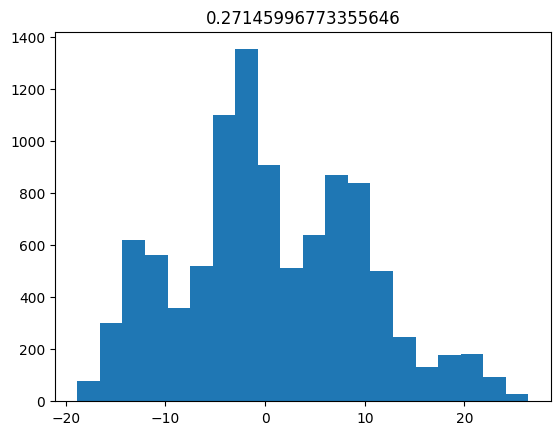

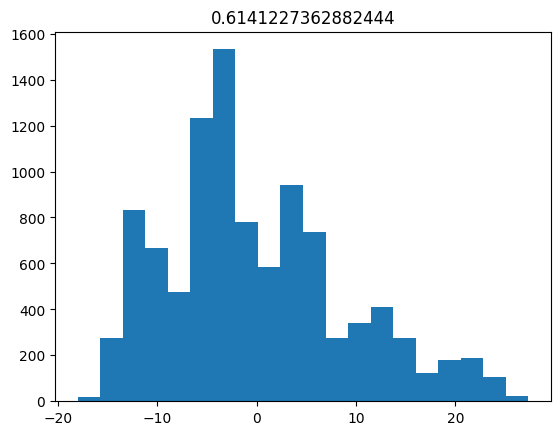

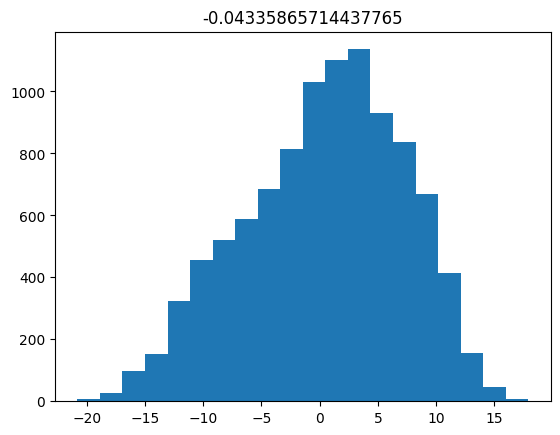

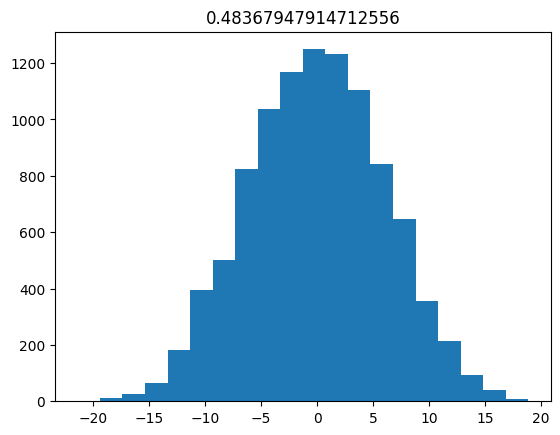

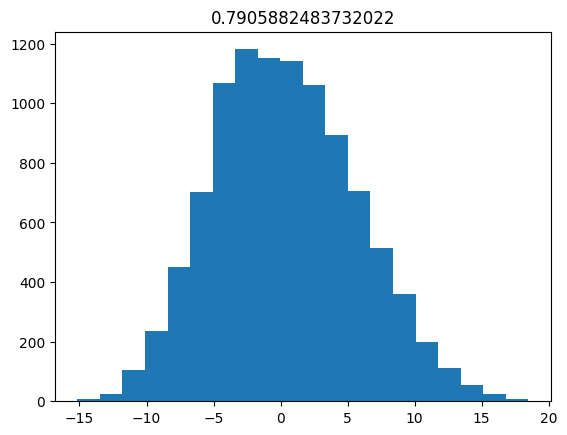

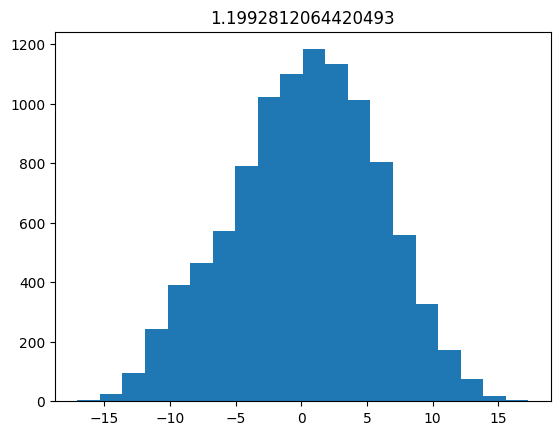

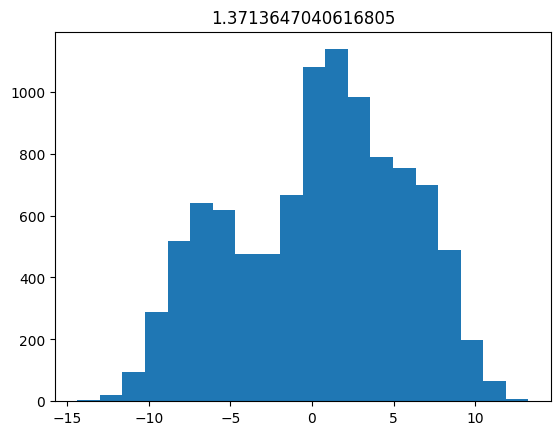

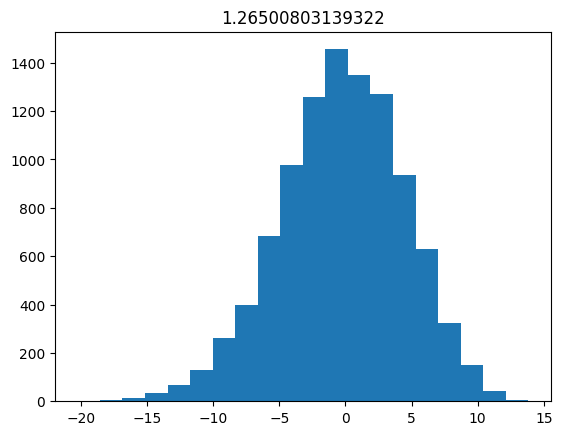

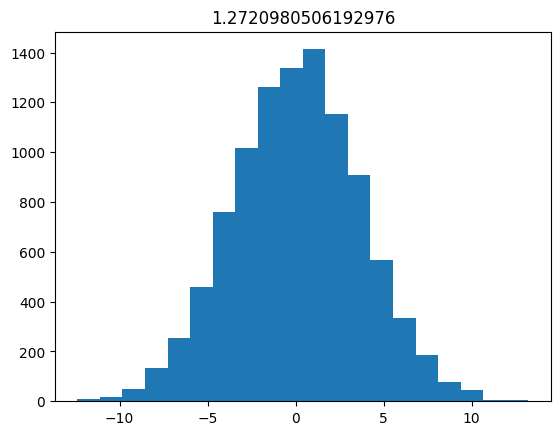

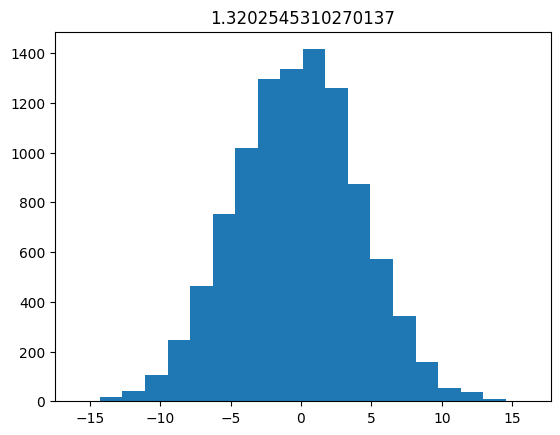

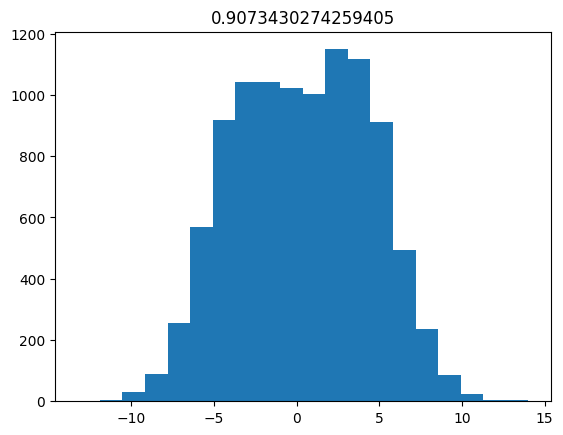

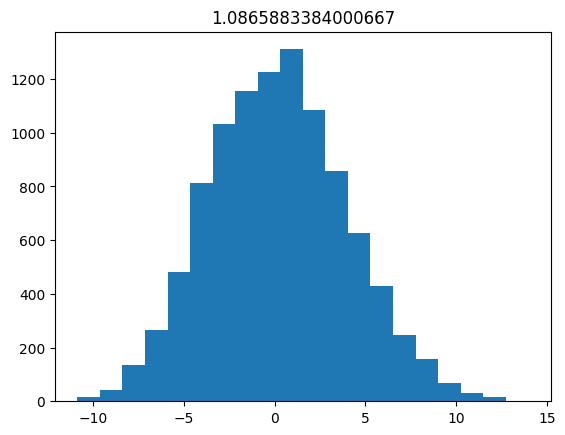

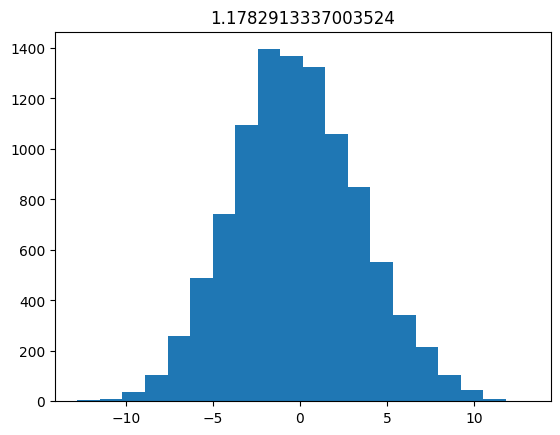

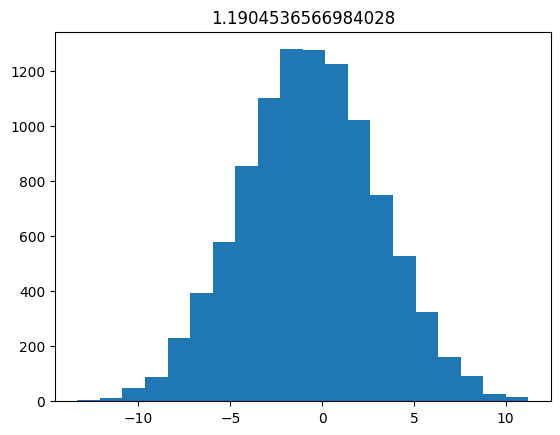

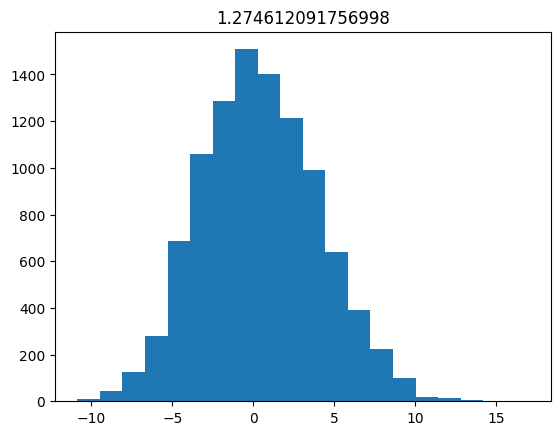

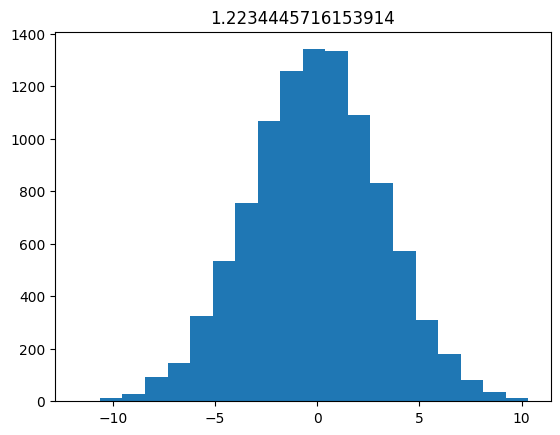

In [230]:
print(ablated_list_pis_in)

for i in range(COMPS):
    plt.hist(s1_att[:, i], bins=20)
    plt.title(ablated_list_pis_in[i])
    plt.show()


In [244]:

fix1 = s1_att.copy()
fix2 = s1_att.copy()
s1_prof_ablate = s1_prof.copy()
#s1_prof_ablate[:, 5:] = 0
sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))
#new_probe = train_linear_probe(tmp[layer_out], sbox_ins%4, epochs=10)
# import random
# f1_i = random.randint(0, s1_att.shape[0])
# f2_i = random.randint(0, s1_att.shape[0])
fix1[:,2] = -5#s1_prof[f1_i, 2]
fix2[:, 2] = 10#s1_prof[f2_i, 2]
#mask_diff = dataset.share5_profiling[target_byte, f1_i].astype(np.uint8)^ dataset.share5_profiling[target_byte,f2_i].astype(np.uint8) 
#print(dataset.attack_masks.shape)
preds_f1 = new_probe.predict(new_model_for_probe.predict(pca.inverse_transform(fix1)))
preds_f2 = new_probe.predict(new_model_for_probe.predict(pca.inverse_transform(fix2)))
#print(mask_diff, tf.keras.metrics.KLDivergence()(preds_f1,transform_with_bitwise_difference(preds_f2, mask_diff, 256)))

scores = []
scores_dist = []
for i in range(256):
 scores.append(tf.keras.metrics.KLDivergence()(preds_f1,transform_with_bitwise_difference(preds_f2, i, 256)).numpy())
 scores_dist.append(np.average(np.sum(np.abs(preds_f1 - transform_with_bitwise_difference(preds_f2, i, 256)), axis=1)))
 #print(i, tf.keras.losses.KLDivergence()(preds_f2,transform_with_bitwise_difference(preds_f1, i)), tf.keras.losses.KLDivergence()(preds_f1,transform_with_bitwise_difference(preds_f2, i)))
 #print(i, scores[-1], scores_dist[-1])

print( [format(i,'08b') for i in np.argsort(scores)])
print( [format(i,'08b') for i in np.argsort(scores_dist)])



313/313 [==============================] - 0s 829us/step
['00000111', '00000101', '01101011', '10110011', '01001011', '10000101', '00100111', '11100001', '00010011', '00010111', '00000011', '10001001', '01000111', '00111001', '01100001', '01110101', '11001001', '01011011', '00110011', '10010101', '00101001', '01001001', '11001011', '10000011', '01110001', '00001111', '11010111', '00101011', '01000001', '10100001', '10100011', '10001111', '10110111', '01011101', '01010101', '10101011', '00011011', '10000111', '00010001', '00001011', '00110111', '01000011', '10111111', '11010101', '01101111', '01111101', '01100011', '00000000', '01111011', '00110001', '01110111', '10010011', '10010111', '01100101', '11100011', '11000001', '01101101', '00111101', '11000111', '01010111', '10100101', '01001101', '00100011', '10011001', '10001011', '10000001', '00101111', '10011011', '00001101', '10111101', '00000001', '10101001', '01110011', '11111111', '01001111', '00011001', '01100111', '11011011', '11011

In [243]:
fix1 = s1_att.copy()
fix2 = s1_att.copy()
s1_prof_ablate = s1_prof.copy()
#s1_prof_ablate[:, 5:] = 0
sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))
#new_probe = train_linear_probe(tmp[layer_out], sbox_ins%4, epochs=10)
# import random
# f1_i = random.randint(0, s1_att.shape[0])
# f2_i = random.randint(0, s1_att.shape[0])
#fix1[:,2] = 0#s1_prof[f1_i, 2]
# fix2[:, 2] = 0#s1_prof[f2_i, 2]

ablate_higher = s1_att.copy()
ablate_higher[:, 3:9] = 0
ablate_higher[:, 10:] = 0

preds_f1 = new_probe.predict(new_model_for_probe.predict(pca.inverse_transform(fix1)))
preds_f2 = new_probe.predict(new_model_for_probe.predict(pca.inverse_transform(ablate_higher)))

tf.keras.metrics.KLDivergence()(preds_f1, preds_f2)


313/313 [==============================] - 0s 836us/step


<tf.Tensor: shape=(), dtype=float32, numpy=1.5976377>